# 02 · The model ladder

**Purpose.** Take the data understanding from notebook 01 and turn it into a decision:
which recommendation approach we would build, and on what evidence.

**How to read this.** Every model is fitted through the `recommender` package — nothing
is re-implemented in a cell, so what you see here is exactly what
`scripts/run_model.py` measures and exactly what `docs/RESULTS.md` records. The ladder
is deliberately walked in order, cheapest first, and each rung has to justify itself
against the one below.

**The honest summary, before any of the numbers.** No single model wins. Accuracy and
catalogue coverage run in almost exactly opposite directions, so the choice is a design
decision about what the product is for — not a leaderboard.

Runtime: about nine minutes on a laptop, most of it the TF-IDF evaluation.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recommender.data import CATALOG_SIZE, build_interactions, load
from recommender.eval import comparison_table, evaluate
from recommender.gallery import ANCHORS, build_gallery
from recommender.models import fit_model
from recommender.models.als import ALSRecommender
from recommender.models.content_tfidf import TfidfRecommender
from recommender.models.embeddings import EmbeddingRecommender
from recommender.models.item_item import ItemItemRecommender
from recommender.models.popularity import PopularityRecommender
from recommender.split import make_split

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 46)

started = time.perf_counter()
catalog = load()
print(f"loaded {len(catalog.ratings):,} ratings, {len(catalog.books):,} books "
      f"({catalog.n_repaired} malformed rows repaired) in {time.perf_counter() - started:.0f}s")

loaded 1,149,780 ratings, 271,360 books (3 malformed rows repaired) in 1s


---
## 1 · The split, and why it is the most important cell in this notebook

Every number below is only as trustworthy as the split it was measured on, so the split
is defined once, in `recommender.split`, and every model cites it.

**Per-user leave-one-out, seed 42.** A user is eligible if they have at least 5 explicit
ratings *and* at least one rating of 8 or more — the first so a profile survives the
holdout, the second so there is something worth predicting. One item is held out per
eligible user, drawn at random from their ratings ≥ 8. Everything else is train,
including all 716,109 implicit interactions and every interaction of non-eligible users.

**Why not a temporal split.** `Ratings.csv` has no time column at all. "Train on the
past, test on the future" is not expressible on this dataset. With client production
logs we would split temporally, and a random split there would leak future behaviour
into training. Saying this plainly is more useful than describing a split the data
cannot support.

In [2]:
split = make_split(catalog.ratings)
train = build_interactions(split.train, weights="binary")
catalog_isbns = set(catalog.books["ISBN"])

print(split.describe())
print(f"\ntrain matrix: {train.n_users:,} users x {train.n_items:,} items, {train.matrix.nnz:,} interactions")

# Leakage check, run in the notebook rather than asserted in prose.
holdout_in_train = sum(
    1
    for user, isbn in zip(split.test["User-ID"], split.test["ISBN"], strict=True)
    if (r := train.user_index.get(int(user))) is not None
    and (c := train.item_index.get(isbn)) is not None
    and train.matrix[r, c] != 0
)
print(f"held-out pairs found in the train matrix: {holdout_in_train}  (must be 0)")

leave-one-out, seed=42: eligible = users with >=5 explicit ratings and >=1 rating >=8; one held-out item per eligible user drawn from their ratings >=8. 13,581 eligible users, 1,136,199 train interactions.

train matrix: 105,283 users x 338,496 items, 1,136,199 interactions
held-out pairs found in the train matrix: 0  (must be 0)


### The ceiling nobody can beat

Before measuring any model, it is worth knowing what perfect would look like — because
it is not 100%.

In [3]:
in_train = split.test["ISBN"].isin(set(train.item_ids)).mean()
has_meta = split.test["ISBN"].isin(catalog_isbns).mean()
either = split.test["ISBN"].isin(set(train.item_ids) | catalog_isbns).mean()

print(f"held-out books that appear at all in the train matrix : {in_train:.2%}"
      "   <- ceiling for ANY collaborative model")
print(f"held-out books that have catalogue metadata           : {has_meta:.2%}   <- ceiling for a content model")
print(f"held-out books reachable by one or the other          : {either:.2%}   <- ceiling for a hybrid")
print("\n15.2% of held-out books were that book's ONLY interaction in the entire dataset.")
print("No co-occurrence model can rank an item it has never seen. Read every HitRate below")
print(f"against {in_train:.1%}, not against 100%.")

held-out books that appear at all in the train matrix : 84.81%   <- ceiling for ANY collaborative model
held-out books that have catalogue metadata           : 89.31%   <- ceiling for a content model
held-out books reachable by one or the other          : 95.37%   <- ceiling for a hybrid

15.2% of held-out books were that book's ONLY interaction in the entire dataset.
No co-occurrence model can rank an item it has never seen. Read every HitRate below
against 84.8%, not against 100%.


**Takeaway.** The gap between 84.8% and 95.4% is the coverage argument for a hybrid,
expressed as a bound on achievable accuracy rather than as a slogan. It is the single
most useful number in this notebook.

---
## 2 · Walking the ladder

Each model is fitted on train only and scored with the same three metrics:

- **HitRate@10** — share of users whose held-out book is in their top-10. Under
  leave-one-out this *equals* Recall@10, and Precision@10 = HitRate@10 / 10. One number,
  three names; reporting all three would be one measurement dressed up as corroboration.
- **Coverage@10** — distinct catalogue books appearing in anyone's top-10, over all
  271,360. This measures the reach argument instead of asserting it.
- **Novelty@10** — mean `-log2` smoothed popularity share. Higher means deeper in the tail.

Accuracy alone cannot be the verdict here: with the top 1% of books holding 25.1% of all
interactions, a model can win HitRate by recommending bestsellers to everybody.

In [4]:
results, models = [], {}


def run(model, label=None):
    """Fit on train, evaluate on the pinned split, keep the model for the gallery.

    Fitting goes through recommender.models.fit_model -- the same dispatch
    scripts/run_model.py uses -- so the notebook and the ledger cannot drift apart
    about which matrix a model was trained on.
    """
    t0 = time.perf_counter()
    fit_model(model, train, catalog, split.train)
    fit_seconds = time.perf_counter() - t0
    result = evaluate(model, split, train, catalog_isbns=catalog_isbns)
    results.append(result)
    models[label or model.name] = model
    print(f"{result}   [fit {fit_seconds:.0f}s]")
    return result


_ = run(PopularityRecommender())

popularity                   HitRate@10=0.0145  Coverage@10=0.019%  Novelty@10=10.81  (13,581 users, 1s)   [fit 0s]


### 2.1 · Popularity — the reference row

Not a recommender: it hands nearly the same ten books to everyone. It is here because
it calibrates everything else. On a catalogue where the top 1% of books absorb a quarter
of all interactions, "recommend the bestsellers" is a genuinely strong bet.

The interesting half of its row is coverage.

In [5]:
popularity = models["popularity"]
recommended = results[0].recommendations
distinct = {isbn for isbn in recommended.ravel().tolist() if isbn is not None}
print(f"distinct books the baseline ever recommends, "
      f"across all {len(split.test):,} users: {len(distinct)}")
print(f"share of the {CATALOG_SIZE:,}-book catalogue: {len(distinct) / CATALOG_SIZE:.3%}\n")

# Where does its hit rate actually come from?
support = np.array([
    train.item_popularity[train.item_index[b]] if b in train.item_index else 0
    for b in split.test["ISBN"]
])
hits = (recommended == split.test["ISBN"].to_numpy().reshape(-1, 1)).any(axis=1)
print(f"{'held-out book support':>22} {'users':>7} {'HitRate@10':>11}")
for lo, hi, label in [(0, 0, "0 (unreachable)"), (1, 4, "1-4"), (5, 49, "5-49"), (50, 10**9, "50+")]:
    mask = (support >= lo) & (support <= hi)
    print(f"{label:>22} {mask.sum():>7,} {hits[mask].mean():>11.4f}")

distinct books the baseline ever recommends, across all 13,581 users: 52
share of the 271,360-book catalogue: 0.019%

 held-out book support   users  HitRate@10
       0 (unreachable)   2,063      0.0000
                   1-4   2,759      0.0000
                  5-49   5,046      0.0000
                   50+   3,713      0.0531


**Takeaway.** The baseline is not a *weak* benchmark, it is a **narrow** one. It scores
exactly zero for every user whose held-out book has fewer than 50 interactions — 73% of
them — and its entire hit rate comes from users who were going to be given a bestseller
anyway. The aggregate number hides this completely, which is a good argument for never
reporting a single aggregate.

### 2.2 · Item-item CF — the core hypothesis

The product takes a book and returns similar books, with no user identity at query time.
Item-item answers exactly that question natively: the model *is* a table of book
neighbourhoods.

Similarity is **shrunk cosine** over the binarized interaction matrix:
`co_occurrence(i,j) / (sqrt(support_i · support_j) + λ)`. Plain cosine is hostile here —
58% of books have exactly one rating, so two books sharing their single reader score a
perfect 1.0, and a similarity built from one coincidence outranks one built from four
hundred readers. The shrinkage term costs popular pairs almost nothing and divides
one-off pairs by a constant they cannot compete with.

λ = 10 and 50 neighbours per item were chosen on a **validation split carved out of
train** (seed 43), never on the evaluation holdout.

In [6]:
_ = run(ItemItemRecommender())
_ = run(ItemItemRecommender(signal="explicit", name="item-item (explicit-only)"),
        label="item-item (explicit-only)")

item-item                    HitRate@10=0.0546  Coverage@10=9.064%  Novelty@10=14.91  (13,581 users, 2s)   [fit 21s]


item-item (explicit-only)    HitRate@10=0.0379  Coverage@10=10.739%  Novelty@10=16.59  (13,581 users, 1s)   [fit 5s]


Note what the second row is. It is the *same model* on a matrix built from graded
ratings alone — the ablation that turns the signal decision into a measurement instead
of an assumption.

In [7]:
binary_hit = results[1].hit_rate_at_10
explicit_hit = results[2].hit_rate_at_10
print(f"all interactions (binarized): HitRate@10 = {binary_hit:.4f}")
print(f"explicit ratings only       : HitRate@10 = {explicit_hit:.4f}")
print(f"\ncost of discarding the 62.3% of rows that carry no grade: "
      f"{1 - explicit_hit / binary_hit:.0%} of the hit rate")
print(f"but explicit-only wins on coverage: {results[2].coverage_at_10:.3%} vs {results[1].coverage_at_10:.3%}")

all interactions (binarized): HitRate@10 = 0.0546
explicit ratings only       : HitRate@10 = 0.0379

cost of discarding the 62.3% of rows that carry no grade: 31% of the hit rate
but explicit-only wins on coverage: 10.739% vs 9.064%


**Takeaway.** An ungraded interaction is weaker evidence than a 10, but it is not noise —
discarding it costs 31% of the hit rate. The counter-current is real and belongs in the
same sentence: the sparser explicit-only matrix spreads its recommendations more thinly,
so it *wins* on coverage and novelty. Binarized-everything wins where it counts and loses
where it does not.

### 2.3 · ALS — the same story one rung up

ALS is not an alternative to item-item, it is a continuation of it: the item factors
*are* item embeddings, and similarity is a dot product between them. It also produces
user factors from the same fit, so personalization comes free the day the product knows
who is asking — and it is the one model here with a first-class Spark implementation,
which makes the Part 3 Databricks story a port rather than a rewrite.

The explicit ratings earn their keep here as **confidence weights**: the matrix carries
`1 + α·rating`, so an ungraded interaction still counts (confidence 1) while a book
graded 10 counts eleven times as much. Note what this does *not* claim — a low rating is
not a negative signal. ALS can express strength of positive evidence and nothing else.

In [8]:
_ = run(ALSRecommender())

als                          HitRate@10=0.0451  Coverage@10=0.835%  Novelty@10=12.63  (13,581 users, 35s)   [fit 93s]


**Takeaway.** ALS loses to item-item on all three metrics at once, which is what the
literature predicts for data this sparse — and the popularity-bias study run *on
Book-Crossing specifically* (Naghiaei et al. 2022) flags matrix-factorization models as
bias amplifiers. Measuring it beats citing it. ALS stays in the ladder for the free
personalization and the Spark bridge, not for its score. §4 shows the one thing it is
clearly best at.

### 2.4 · The content layers — reaching the catalogue CF cannot see

Both content models score a book from its title and author, so both can rank a book
nobody has ever touched. That is the entire point: collaborative filtering is
structurally blind to 15.2% of the held-out books and, after standard filtering, to 95%
of the catalogue.

**TF-IDF** uses character n-grams rather than words, deliberately — the catalogue is
multilingual and riddled with edition variants, and character n-grams degrade gracefully
across both where a word vocabulary would treat *Ringe* and *Rings* as unrelated.

**Embeddings** use a multilingual sentence transformer, which places *Der Herr der Ringe*
near *The Lord of the Rings* because it was trained to rather than because they share
characters. Vectors for all 271,360 books are cached under `artifacts/`.

In [9]:
_ = run(TfidfRecommender())      # the slow one: ~5 minutes
_ = run(EmbeddingRecommender())  # fast, vectors come from the cache

content-tfidf                HitRate@10=0.0228  Coverage@10=16.616%  Novelty@10=17.63  (13,581 users, 318s)   [fit 10s]


content-embeddings           HitRate@10=0.0109  Coverage@10=23.911%  Novelty@10=18.42  (13,581 users, 34s)   [fit 0s]


**Takeaway.** Both reach far more of the catalogue than any collaborative model and both
score worse — the embedding layer lands *below the popularity baseline* on accuracy. That
is the honest shape of a content layer: it is a coverage and cold-start mechanism, not a
scoring core, and it would be dishonest to promote the embedding model simply because it
is the deep-learning component.

---
## 3 · The comparison table

Same split, same metrics, same run.

In [10]:
table = comparison_table(results).drop(columns=["params"]).sort_values("HitRate@10", ascending=False)
display(table.reset_index(drop=True))

,model,HitRate@10,Coverage@10,Novelty@10,users,seconds
0,item-item,0.0546,0.09064,14.91,13581,1.8
1,als,0.0451,0.00835,12.63,13581,35.3
2,item-item (explicit-only),0.0379,0.10739,16.59,13581,0.6
3,content-tfidf,0.0228,0.16616,17.63,13581,318.2
4,popularity,0.0145,0.00019,10.81,13581,0.7
5,content-embeddings,0.0109,0.23911,18.42,13581,33.9


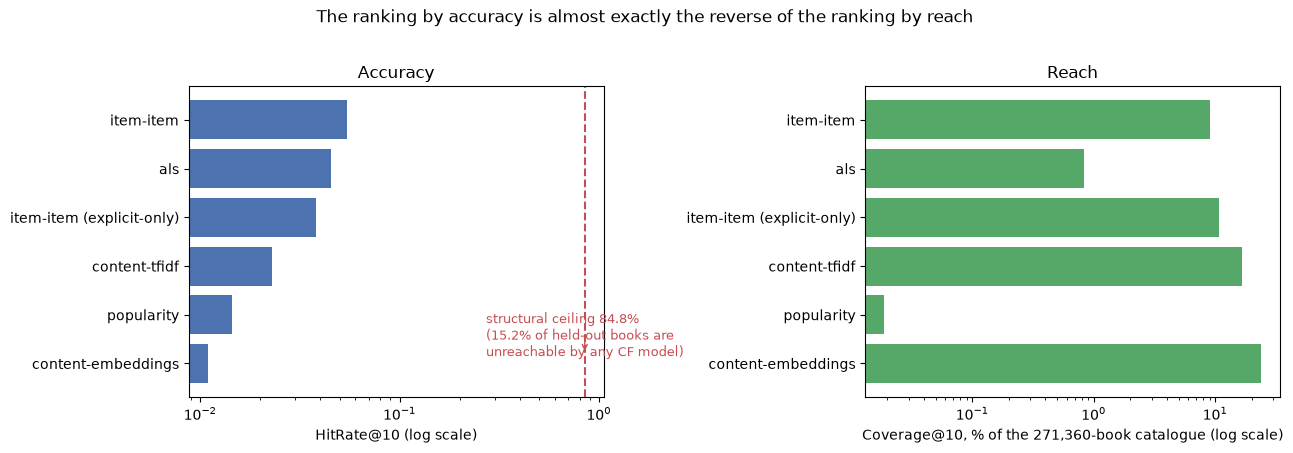

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ordered = sorted(results, key=lambda r: r.hit_rate_at_10)
labels = [r.model for r in ordered]

axes[0].barh(labels, [r.hit_rate_at_10 for r in ordered], color="#4c72b0")
axes[0].axvline(in_train, color="#c44e52", linestyle="--")
axes[0].annotate(f"structural ceiling {in_train:.1%}\n(15.2% of held-out books are\nunreachable by any CF model)",
                 xy=(in_train, 0.2), xytext=(in_train * 0.32, 0.15), color="#c44e52", fontsize=9,
                 arrowprops={"arrowstyle": "->", "color": "#c44e52"})
axes[0].set_xscale("log")
axes[0].set_xlabel("HitRate@10 (log scale)")
axes[0].set_title("Accuracy")

axes[1].barh(labels, [r.coverage_at_10 * 100 for r in ordered], color="#55a868")
axes[1].set_xscale("log")
axes[1].set_xlabel("Coverage@10, % of the 271,360-book catalogue (log scale)")
axes[1].set_title("Reach")

fig.suptitle("The ranking by accuracy is almost exactly the reverse of the ranking by reach", y=1.02)
fig.tight_layout()
plt.show()

**Takeaway.** The table has a shape, and the shape *is* the finding: the accuracy ranking
is almost exactly the reverse of the coverage ranking, with ALS the only exception. There
is no single best model here, so "which model" is the wrong question — the right one is
"which model for which job".

---
## 4 · Face validity: what each model thinks a book is like

The offline harness scores **user histories**. The product is **item-to-item**: paste a
book, get similar books. Those are different questions, and a HitRate cannot see whether
the neighbourhoods a model builds are sensible.

So every model answers the same three books. *The Da Vinci Code* (853 train interactions)
is the easy case. *The Lovely Bones* (1,248) checks we are not just reproducing one
genre cluster. **Harry Potter and the Sorcerer's Stone** (101) is the diagnostic — medium
support, an obvious right answer (the other volumes), and the catalogue holds 120 Harry
Potter rows across editions and languages.

In [12]:
gallery = build_gallery(list(models.values()), catalog, anchors=ANCHORS, k=5)
for label, table in gallery.items():
    print(f"\n=== similar to: {label} ===")
    display(table)


=== similar to: The Da Vinci Code ===


,popularity,item-item,item-item (explicit-only),als,content-tfidf,content-embeddings
rank,,,,,,
1,Wild Animus — Rich Shapero (2501.000),Angels &amp; Demons — Dan Brown (0.248),Angels &amp; Demons — Dan Brown (0.138),Angels &amp; Demons — Dan Brown (0.575),The Da Vinci Code — DAN BROWN (1.000),The Da Vinci Code — Dan Brown (1.000)
2,The Lovely Bones: A Novel — Alice Sebold ...,The Lovely Bones: A Novel — Alice Sebold ...,Middlesex: A Novel — Jeffrey Eugenides (0...,Angels &amp; Demons — Dan Brown (0.557),The Da Vinci Code — Dan Brown (1.000),The Da Vinci Code — Dan Brown (1.000)
3,Divine Secrets of the Ya-Ya Sisterhood: A ...,Harry Potter and the Order of the Phoenix ...,The Narrows: A Novel — Michael Connelly (...,Digital Fortress : A Thriller — Dan Brown ...,The Da Vinci Code — DAN BROWN (1.000),The Da Vinci Code — DAN BROWN (1.000)
4,The Red Tent (Bestselling Backlist) — Anit...,The Secret Life of Bees — Sue Monk Kidd (...,Street Dreams — Faye Kellerman (0.078),Digital Fortress : A Thriller — Dan Brown ...,The Da Vinci Code — DAN BROWN (1.000),The Da Vinci Code — DAN BROWN (1.000)
5,A Painted House — John Grisham (632.000),Balzac and the Little Chinese Seamstress :...,The Lovely Bones: A Novel — Alice Sebold ...,Deception Point — Dan Brown (0.399),The Da Vinci Code — Dan Brown (1.000),The Da Vinci Code — DAN BROWN (1.000)



=== similar to: Harry Potter and the Sorcerer's Stone ===


,popularity,item-item,item-item (explicit-only),als,content-tfidf,content-embeddings
rank,,,,,,
1,Wild Animus — Rich Shapero (2501.000),Deadly Shaker Spring (Sister Rose Callahan...,Harry Potter and the Chamber of Secrets (B...,The Fellowship of the Ring (The Lord of th...,Harry Potter and the Sorcerer's Stone (Boo...,Harry Potter and the Sorcerer's Stone (Boo...
2,The Lovely Bones: A Novel — Alice Sebold ...,Women on the Edge — Martin H. Greenberg (...,The Death of an Irish Tinker: A Peter McGa...,Harry Potter and the Prisoner of Azkaban (...,Harry Potter and the Sorcerer's Stone (Boo...,Harry Potter and the Sorcerer's Stone (Boo...
3,The Da Vinci Code — Dan Brown (853.000),Harry Potter and the Chamber of Secrets (B...,Angel of Death — Jack Higgins (0.100),Harry Potter and the Chamber of Secrets (B...,Harry Potter and the Sorcerer's Stone (Boo...,Harry Potter and the Sorcerer's Stone (Boo...
4,Divine Secrets of the Ya-Ya Sisterhood: A ...,Harry Potter and the Prisoner of Azkaban (...,Chicago: A Guide to Recent Architecture (A...,Harry Potter and the Goblet of Fire (Book ...,Harry Potter and the Sorcerer's Stone — J....,Harry Potter and the Sorcerer's Stone (Boo...
5,The Red Tent (Bestselling Backlist) — Anit...,A Cat on Jingle Bell Rock: An Alice Nestle...,McNally's Caper (Archy McNally Novels (Pap...,The Great Train Robbery — Michael Crichton...,Harry Potter and the Sorcerer's Stone (Boo...,Harry Potter and the Sorcerer's Stone (Urd...



=== similar to: The Lovely Bones ===


,popularity,item-item,item-item (explicit-only),als,content-tfidf,content-embeddings
rank,,,,,,
1,Wild Animus — Rich Shapero (2501.000),Lucky : A Memoir — Alice Sebold (0.206),Lucky : A Memoir — Alice Sebold (0.090),Lucky : A Memoir — Alice Sebold (0.453),The Lovely Bones — Alice Sebold (0.895),The Lovely Bones — Alice Sebold (0.916)
2,The Da Vinci Code — Dan Brown (853.000),The Da Vinci Code — Dan Brown (0.173),Where the Heart Is (Oprah's Book Club (Pap...,[no metadata: 0394281780] (0.331),The Lovely Bones — Alice Sebold (0.895),The Lovely Bones — Alice Sebold (0.916)
3,Divine Secrets of the Ya-Ya Sisterhood: A ...,The Nanny Diaries: A Novel — Emma McLaughl...,Lucky — Alice Sebold (0.081),Of Love and Shadows — Isabel Allende (0.322),The Lovely Bones — Alice Sebold (0.895),The Lovely Bones — Alice Sebold (0.916)
4,The Red Tent (Bestselling Backlist) — Anit...,The Red Tent (Bestselling Backlist) — Anit...,The Da Vinci Code — Dan Brown (0.077),SMART WOMEN : A Story of Hope — Judy Blume...,The Lovely Bones — Alice Sebold (0.895),The Lovely Bones — Alice Sebold (0.916)
5,A Painted House — John Grisham (632.000),Midwives: A Novel — Chris Bohjalian (0.163),The Master Butchers Singing Club : A Novel...,Lucky — Alice Sebold (0.307),The Lovely Bones (Reader's Companion) — Al...,The Lovely Bones (Reader's Companion) — Al...


**Takeaway — the Harry Potter column is the whole story in one table.**

- **popularity** returns bestsellers. It has no notion of similarity at all; the column is
  a control.
- **item-item** returns two unrelated obscure books before it finds *Chamber of Secrets*.
  They share four readers out of six, which shrinkage at λ=10 does not damp enough. λ was
  tuned for HitRate, and HitRate is dominated by *popular* held-out books — so it is
  under-damped for exactly the surface the product exposes.
- **the content models** return *the same book again*: five ISBNs of *Sorcerer's Stone*
  in different editions. Textually a reprint and the original are identical, so no text
  model can tell "same work" from "similar work".
- **ALS is the only model that answers the question a reader would ask** — *Fellowship of
  the Ring*, then Harry Potter 3, 2 and 4. The model that scores *worst* on the metrics
  has the best neighbourhoods, because the metrics and the product measure different things.

That divergence is not a caveat to mention in passing. It is the reason both numbers and
galleries are in this notebook.

In [13]:
# The duplicate problem, measured rather than eyeballed.
work_key = (catalog.books["Book-Title"].fillna("").str.lower().str.strip() + "|"
            + catalog.books["Book-Author"].fillna("").str.lower().str.strip())
work_of = dict(zip(catalog.books["ISBN"], work_key, strict=True))

print(f"{'model':>26} {'slots that are another edition of a book the user already has':>62}")
for result in results:
    duplicate = total = 0
    for row, user in enumerate(split.test["User-ID"].to_numpy()):
        user_row = train.user_index[int(user)]
        lo, hi = train.matrix.indptr[user_row], train.matrix.indptr[user_row + 1]
        own = {work_of.get(b) for b in train.item_ids[train.matrix.indices[lo:hi]].tolist()} - {None}
        picks = [p for p in result.recommendations[row].tolist() if p is not None]
        duplicate += sum(1 for p in picks if work_of.get(p) in own)
        total += len(picks)
    print(f"{result.model:>26} {duplicate / total:>61.1%}")

                     model  slots that are another edition of a book the user already has


                popularity                                                          0.3%


                 item-item                                                          0.7%


 item-item (explicit-only)                                                          3.2%


                       als                                                          1.2%


             content-tfidf                                                         31.6%


        content-embeddings                                                          8.2%


**Takeaway.** Edition clustering is not a data-hygiene nicety, it is a precondition for
shipping a content model as the app's similarity engine. Nearly a third of TF-IDF's
recommendation slots point at a book the user already owns in another edition.

---
## 5 · What these numbers are not

**They are one split.** Seeded and reproducible, but one draw. No confidence intervals
are reported here, and differences of a few tenths of a percent should not be read as
real.

**They are offline.** Every metric asks "was the held-out book in the top ten", which is a
proxy for "would a reader click, buy, or enjoy this". A recommendation the user has never
heard of scores zero whether it was a brilliant discovery or a mistake. A live A/B test
is the only thing that settles the real question, and that stays true however favourable
this table looks.

**They inherit the dataset's quirks.** A 2004 web crawl with no timestamps, 10.3% of
interactions unjoinable to a book we could display, and 40,675 ISBNs that are alternative
editions of a work already in the catalogue.

**What we protected against, and how.** Fitting only ever touched train — the leakage
check at the top of this notebook is run, not asserted. Hyperparameters were chosen on a
validation split carved out of train, never on the evaluation holdout. The metrics are
the same three for every model, computed by one function. And the negative results are in
`docs/RESULTS.md` next to the positive ones, because a ledger you can only read one way
is a brochure.

---
## 6 · What we would build

**Item-item CF as the scoring core.** It wins accuracy by a clear margin (3.8× the
baseline), it answers the product's actual question natively, it trains in 21 seconds, and
it is explainable — "readers of this book also read that one" is a sentence a customer
understands and a shop can defend.

**A content layer beside it, not behind it.** Not as a cold-start footnote: collaborative
filtering is structurally incapable of reaching 15.2% of held-out books and 95% of the
catalogue. The union of both raises the achievable ceiling from 84.8% to 95.4%, and the
two models overlap on only 7,451 of the 62,236 catalogue books they reach between them.

**ALS kept in the plan, for what the metrics do not show.** Free personalization from the
same fit, the best item-to-item neighbourhoods of any model here, and the only model that ports
to Spark without a rewrite.

**Edition clustering first, before any of it ships.** It is the one fix that improves
every model's product surface at once, and today it is what stands between the content
layer and a demo that recommends the book the user is holding.

Every number above traces to a line in [`docs/RESULTS.md`](../docs/RESULTS.md).

---

**Follow-up (M11, measured after this notebook was run).** Edition clustering was built
and measured; see `docs/RESULTS.md` L40–L47 and `docs/model_selection.md` §10. Three
things changed above:

- The 31.6% duplicate rate in §4 was measured with an exact title+author key. A key that
  also absorbs author-spelling variants finds **39.1% of slots and 81.5% of users** (L45).
- Deduplicating at serving time removes them at no accuracy cost and *raises* TF-IDF's
  HitRate to **0.0277** (L45) — but the collaborative surfaces come out clean while the
  content ones still return translations and alternate titles of the anchor (L47).
- Clustering *before* training lifts item-item from 0.0546 to **0.0644, +18%** (L44) —
  the largest single accuracy gain in the project, and it is a data-prep change.

The "7,451 of 62,236" figure above is the corrected counting basis (L46); this cell
originally said "~75,000", which mixed two different denominators.
